# Dimensionality Reduction

## Introduction

Dimensionality Reduction is the process of reducing the number of input features while preserving as much useful information as possible.

It helps simplify complex datasets, reduce training time, improve model performance, and make high-dimensional data easier to visualize.

### Objectives

- Reduce the number of features
- Remove redundant information
- Improve computational efficiency
- Reduce overfitting
- Visualize high-dimensional data

In [1]:
# Import Libraries 
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [2]:
df = sns.load_dataset("titanic")

In [4]:
df["age"] = df["age"].fillna(df["age"].median())
df["fare"] = df["fare"].fillna(df["fare"].median())

# Principal Component Analysis (PCA)

## What is PCA?

Principal Component Analysis (PCA) is an **unsupervised dimensionality reduction technique**.

Instead of selecting existing features, PCA creates new features called **Principal Components**. These components capture the maximum variance present in the original dataset.

PCA is commonly used for visualization, feature compression, and speeding up Machine Learning models.

In [5]:
from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler 

X = df.select_dtypes(include="number").drop(columns=["survived"])

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca[:5])

[[ 1.14066038 -0.07651959]
 [-1.76844507  0.13347858]
 [ 0.87919636 -0.72660565]
 [-1.45810298  0.07155456]
 [ 0.56125154 -0.94371301]]


### Visualizing PCA Components

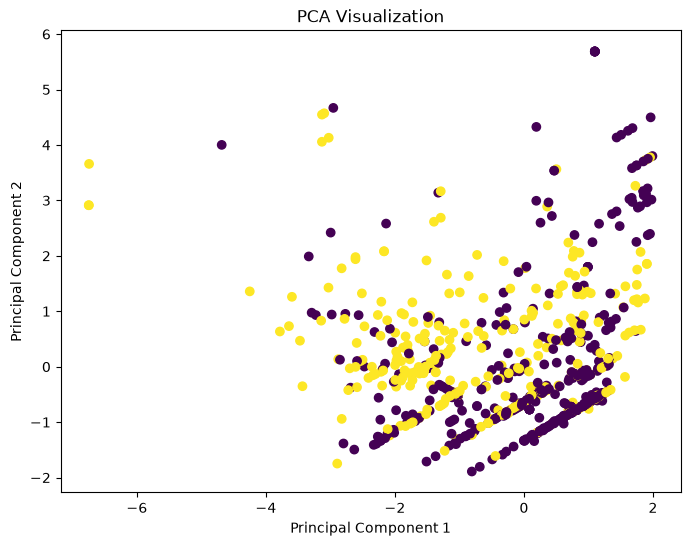

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1], c=df["survived"])

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")

plt.show()

# Linear Discriminant Analysis (LDA)

## What is LDA?

Linear Discriminant Analysis (LDA) is a **supervised dimensionality reduction technique**.

Unlike PCA, LDA uses the target variable to maximize the separation between different classes.

It is mainly used for classification problems.

In [11]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

X = df.select_dtypes(include="number").drop(columns=["survived"])
Y = df["survived"]

lda = LinearDiscriminantAnalysis(n_components=1)

X_lda = lda.fit_transform(X,Y)

print(X_lda[:5])

[[-0.80533484]
 [ 1.10135652]
 [-0.73253274]
 [ 1.14911244]
 [-1.11160879]]


### LDA Visualization

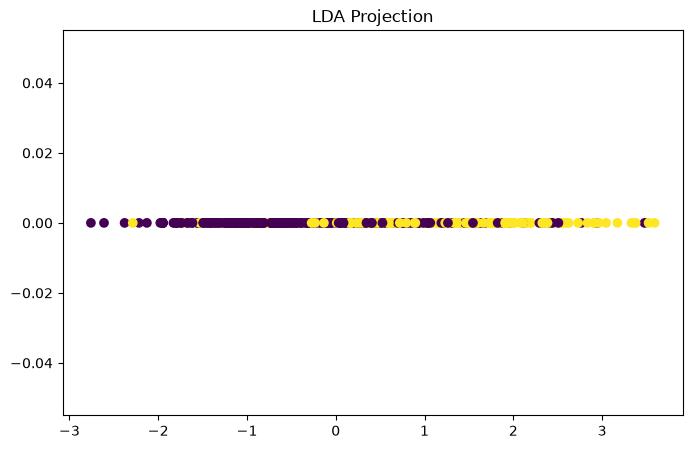

In [12]:
plt.figure(figsize=(8,5))

plt.scatter(X_lda, [0]*len(X_lda), c=Y)

plt.title("LDA Projection")
plt.show()

# t-Distributed Stochastic Neighbor Embedding (t-SNE)

## What is t-SNE?

t-SNE is a **non-linear dimensionality reduction technique** mainly used for data visualization.

It projects high-dimensional data into two or three dimensions while preserving local relationships between data points.

It is commonly used to visualize clusters.

In [13]:
from sklearn.manifold import TSNE 

tsne = TSNE(n_components=2,random_state=42)

X_tsne = tsne.fit_transform(X_scaled)

print(X_tsne[:5])

[[ 15.589429    8.7751665]
 [-30.889387    9.281449 ]
 [ 36.17782    -5.9140534]
 [-31.946558    9.1036825]
 [  6.9832087 -12.169027 ]]


### t-SNE Visualization

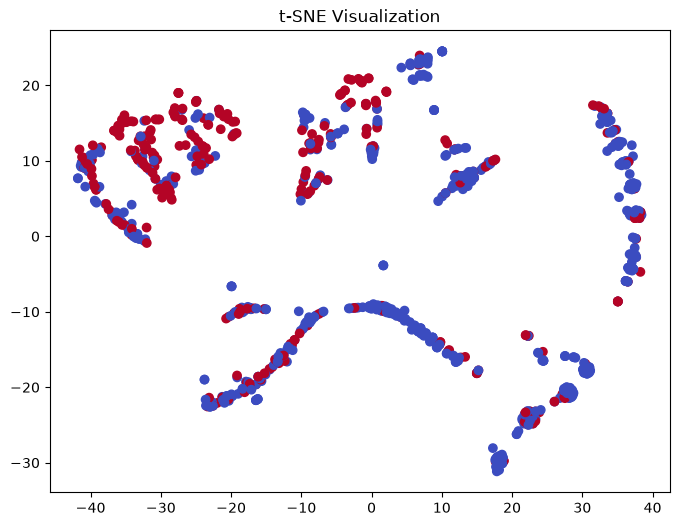

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(X_tsne[:,0],X_tsne[:,1],c=Y, cmap="coolwarm")

plt.title("t-SNE Visualization")

plt.show()

# Uniform Manifold Approximation and Projection (UMAP)

## What is UMAP?

UMAP is another non-linear dimensionality reduction technique.

It preserves both local and global data structure while being faster than t-SNE on large datasets.

UMAP is widely used for visualization and feature reduction.

In [ ]:
%pip install umap-learn

In [24]:
import umap

umap_model = umap.UMAP(n_components=2, random_state=42)

X_umap = umap_model.fit_transform(X_scaled)

print(X_umap[:5])


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[[-2.0345325  9.753906 ]
 [10.439073   4.748523 ]
 [20.369787   8.235854 ]
 [10.684046   4.7689786]
 [11.9116125 -4.352105 ]]


### UMAP Visualization

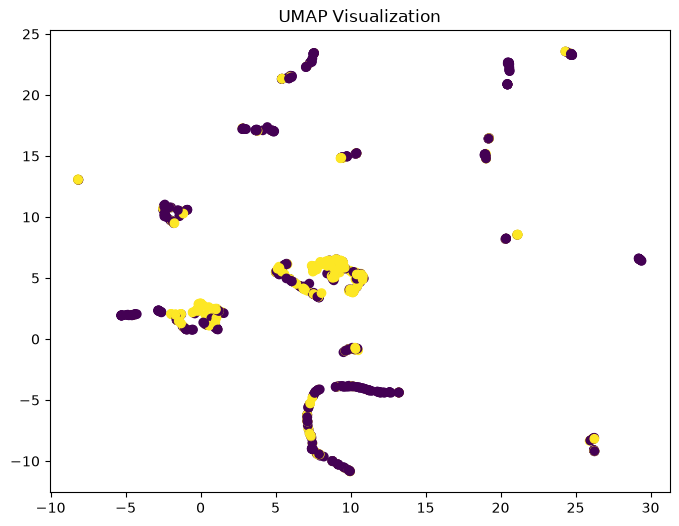

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=Y
)
plt.title("UMAP Visualization")
plt.show()

# Autoencoders

## What are Autoencoders?

Autoencoders are **Deep Learning models** used for dimensionality reduction.

They consist of two parts:

- Encoder
- Decoder

The encoder compresses the input into a lower-dimensional representation, while the decoder reconstructs the original data.

Autoencoders are effective for capturing complex non-linear relationships.

In [ ]:
%pip install tensorflow

In [33]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model 

input_dim = X_scaled.shape[1]

encoding_dim = 2

input_layer = Input(shape=(input_dim,))

encoded = Dense(encoding_dim, activation="relu")(input_layer)

decoded = Dense(input_dim, activation="sigmoid")(encoded)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(optimizer="adam", loss="mse")

autoencoder.fit(X_scaled, X_scaled, epochs= 20, batch_size = 32, verbose=0)

encoder = Model(input_layer, encoded)

encoded_data = encoder.predict(X_scaled)

print(encoded_data[:5])


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
[[0.8630376  0.23486054]
 [0.24130017 2.1569777 ]
 [1.6675749  0.        ]
 [0.47899914 2.001131  ]
 [1.9623349  0.        ]]


### Autoencoder Visualization

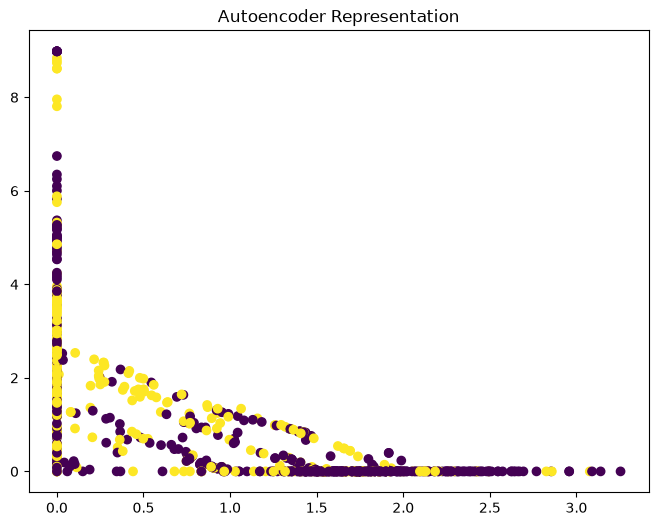

In [34]:
plt.figure(figsize=(8,6))

plt.scatter( encoded_data[:,0], encoded_data[:,1], c=Y)

plt.title("Autoencoder Representation")
plt.show()

---
## 📝 Note

Dimensionality Reduction simplifies high-dimensional datasets while preserving important information. Choosing the right technique depends on the dataset, problem type, and the goal of the Machine Learning project.